In [ ]:
# %matplotlib inline

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lincolnzh/martianlunar-crater-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'martianlunar-crater-detection-dataset' dataset.
Path to dataset files: /kaggle/input/martianlunar-crater-detection-dataset


In [ ]:
import os

dataset_path = "/kaggle/input/martianlunar-crater-detection-dataset"

# def print_tree(path, indent=""):
#     try:
#         items = sorted(os.listdir(path))
#     except PermissionError:
#         return

#     folders = [item for item in items if os.path.isdir(os.path.join(path, item))]
#     files = [item for item in items if os.path.isfile(os.path.join(path, item))]

#     print(f"{indent}📁 {os.path.basename(path) or path}")
#     print(f"{indent}   Path    : {path}")
#     print(f"{indent}   Folders : {len(folders)}")
#     print(f"{indent}   Files   : {len(files)}")
#     print(f"{indent}   Folder Names (first 5): {folders[:5]}")
#     print(f"{indent}   File Names   (first 5): {files[:5]}")
#     print(f"{indent}" + "-" * 50)

#     for folder in folders:
#         print_tree(os.path.join(path, folder), indent + "    ")

# print("\nDATASET DIRECTORY STRUCTURE\n")
# print_tree(dataset_path)

## **Dataset Exploration**

In [ ]:
import os

train_img_dir = "/kaggle/input/martianlunar-crater-detection-dataset/craters/train/images"

print("Train Images:", len(os.listdir(train_img_dir)))

Train Images: 98


In [ ]:
from PIL import Image
import os

sizes = []

for file in os.listdir(train_img_dir):
    path = os.path.join(train_img_dir, file)

    img = Image.open(path)

    sizes.append(img.size)

print("Unique Sizes:")
print(set(sizes))

Unique Sizes:
{(640, 640)}


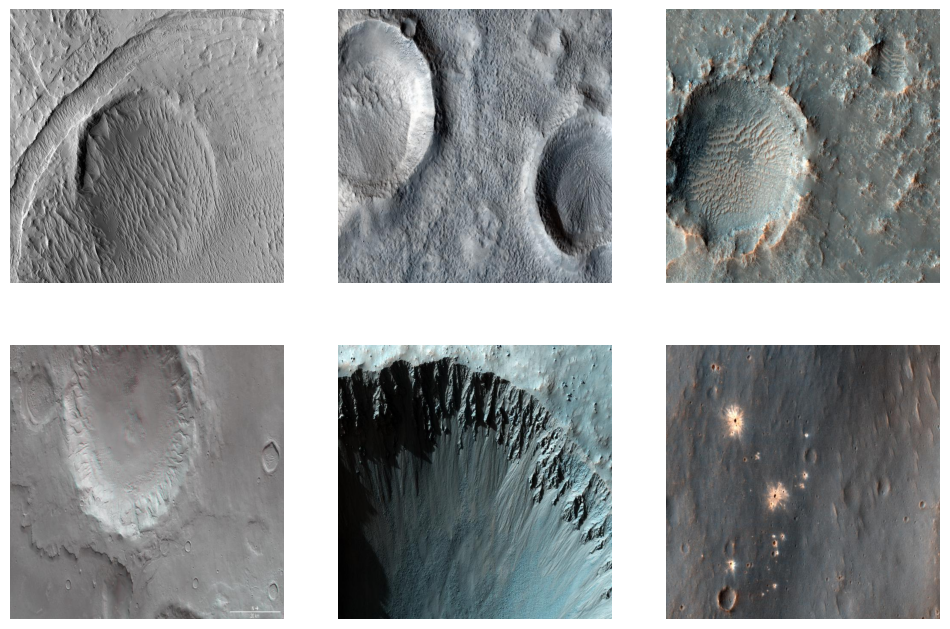

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

files = os.listdir(train_img_dir)

plt.figure(figsize=(12,8))

for i in range(6):

    file = random.choice(files)

    img = Image.open(
        os.path.join(train_img_dir,file)
    )

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

## **Understand Label Files**

In [ ]:
label_dir = "/kaggle/input/martianlunar-crater-detection-dataset/craters/train/labels"

sample_label = os.listdir(label_dir)[0]

with open(
    os.path.join(label_dir,sample_label)
) as f:
    print(f.read())

0 0.4859375 0.25390625 0.040625 0.04921875
0 0.14921875 0.290625 0.0421875 0.053125
0 0.603125 0.4375 0.03125 0.046875
0 0.221875 0.53984375 0.1546875 0.2125
0 0.35546875 0.56171875 0.0609375 0.08203125


In [ ]:
total_craters = 0

for file in os.listdir(label_dir):

    with open(os.path.join(label_dir,file)) as f:
        total_craters += len(f.readlines())

print("Total Craters:", total_craters)

Total Craters: 681


Average Craters Per Image

681/98
	​

≈6.95

≈ 7 craters/image

## **Feature Extraction**

In [ ]:
import os
import pandas as pd
import numpy as np

label_dir = "/kaggle/input/martianlunar-crater-detection-dataset/craters/train/labels"

records = []

for file in os.listdir(label_dir):

    path = os.path.join(label_dir, file)

    crater_count = 0
    crater_areas = []

    with open(path, "r") as f:

        lines = f.readlines()

        crater_count = len(lines)

        for line in lines:

            parts = line.strip().split()

            width = float(parts[3]) * 640
            height = float(parts[4]) * 640

            area = width * height

            crater_areas.append(area)

    avg_area = np.mean(crater_areas) if crater_areas else 0
    max_area = np.max(crater_areas) if crater_areas else 0

    # Density = Number of Creators/Image Area
    density = crater_count / (640 * 640)

    records.append([
        file,
        crater_count,
        avg_area,
        max_area,
        density
    ])

df = pd.DataFrame(
    records,
    columns=[
        "image",
        "crater_count",
        "avg_area",
        "max_area",
        "density"
    ]
)

df.head()

,image,crater_count,avg_area,max_area,density
0,mars_crater--21-_jpg.rf.63688e718106a9b061bb70...,5,3569.700000,13464.00,0.000012
1,mars_crater--85-_jpg.rf.344998b46a84deb2b8802c...,8,23931.406250,152878.50,0.000020
2,05_png.rf.844343145246e51e66a345419e1862bf.txt,18,7834.833333,48237.50,0.000044
3,mars_crater--30-_jpg.rf.0fb68bf5aece1859bc5f08...,7,480.892857,894.25,0.000017
4,011_png.rf.8ac312b4898f0106d10b76952a55d237.txt,10,6915.275000,19458.00,0.000024


In [ ]:
df.describe()

,crater_count,avg_area,max_area,density
count,98.000000,98.000000,98.000000,98.000000
mean,6.948980,37807.866171,54501.385204,0.000017
std,7.779662,86282.590764,93308.875238,0.000019
min,0.000000,0.000000,0.000000,0.000000
25%,1.250000,975.409091,3031.062500,0.000003
50%,4.000000,4767.083333,12999.500000,0.000010
75%,10.000000,14074.880114,47341.875000,0.000024
max,39.000000,365644.750000,366433.500000,0.000095


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image         98 non-null     object 
 1   crater_count  98 non-null     int64  
 2   avg_area      98 non-null     float64
 3   max_area      98 non-null     float64
 4   density       98 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 4.0+ KB


### **Histogram of Crater Counts**

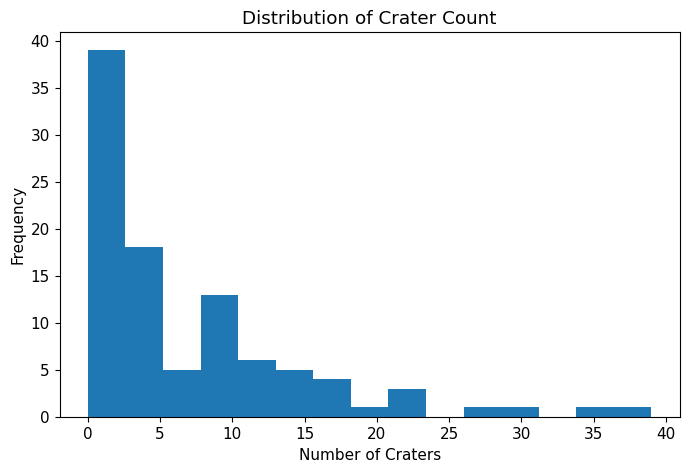

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["crater_count"], bins=15)

plt.title("Distribution of Crater Count")
plt.xlabel("Number of Craters")
plt.ylabel("Frequency")

plt.show()

> The crater count distribution exhibits positive skewness, indicating that most planetary surface images contain relatively few craters while a limited number of images contain heavily cratered terrain.



### **Boxplot**

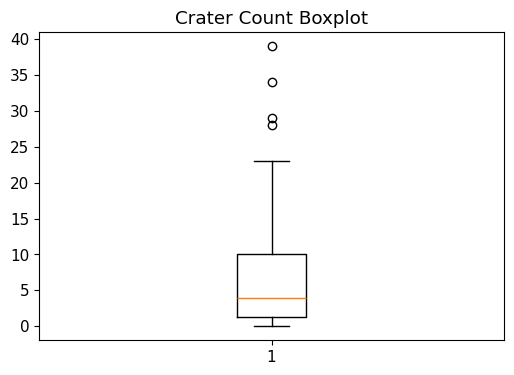

In [ ]:
plt.figure(figsize=(6,4))

plt.boxplot(df["crater_count"])

plt.title("Crater Count Boxplot")

plt.show()

> Outliers were retained because they represent legitimate heavily cratered regions rather than data entry errors.

### **Correlation Matrix**

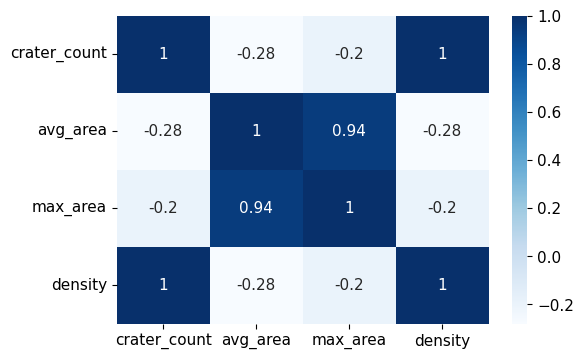

In [ ]:
import seaborn as sns

corr = df.drop("image", axis=1).corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.show()

**Problem 1**

creater_count and density contain almost identical information.

**Problem 2**

avg_area and max_area have correlation = 0.94.

This indicates multicollinearity.

In [ ]:
df["crater_count"].value_counts().sort_index()

,count
crater_count,
0,9
1,16
2,14
3,8
4,3
5,7
6,4
7,1
8,6


In [ ]:
df["label"] = df["crater_count"].apply(
    lambda x: "Safe" if x <= 4 else "Unsafe"
)

df["label"].value_counts()

,count
label,
Safe,50
Unsafe,48


## **Add Image Features**

In [ ]:
import cv2
import numpy as np
from skimage.measure import shannon_entropy
import os

image_dir = "/kaggle/input/martianlunar-crater-detection-dataset/craters/train/images"

entropy_list = []
edge_density_list = []
brightness_list = []
contrast_list = []

for image_file in df["image"]:

    img_name = image_file.replace(".txt", ".jpg")

    img_path = os.path.join(image_dir, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        entropy_list.append(np.nan)
        edge_density_list.append(np.nan)
        brightness_list.append(np.nan)
        contrast_list.append(np.nan)
        continue

    # Entropy
    entropy = shannon_entropy(img)

    # Edge Density
    edges = cv2.Canny(img, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    # Brightness
    brightness = np.mean(img)

    # Contrast
    contrast = np.std(img)

    entropy_list.append(entropy)
    edge_density_list.append(edge_density)
    brightness_list.append(brightness)
    contrast_list.append(contrast)

df["entropy"] = entropy_list
df["edge_density"] = edge_density_list
df["brightness"] = brightness_list
df["contrast"] = contrast_list

In [ ]:
df.head()

,image,crater_count,avg_area,max_area,density,label,entropy,edge_density,brightness,contrast
0,mars_crater--21-_jpg.rf.63688e718106a9b061bb70...,5,3569.700000,13464.00,0.000012,Unsafe,6.380375,0.077380,140.776543,25.391511
1,mars_crater--85-_jpg.rf.344998b46a84deb2b8802c...,8,23931.406250,152878.50,0.000020,Unsafe,6.977090,0.064067,134.423945,32.420526
2,05_png.rf.844343145246e51e66a345419e1862bf.txt,18,7834.833333,48237.50,0.000044,Unsafe,7.265500,0.113079,124.246814,39.540711
3,mars_crater--30-_jpg.rf.0fb68bf5aece1859bc5f08...,7,480.892857,894.25,0.000017,Unsafe,6.802979,0.314653,162.148274,28.178287
4,011_png.rf.8ac312b4898f0106d10b76952a55d237.txt,10,6915.275000,19458.00,0.000024,Unsafe,6.342087,0.083523,125.703547,27.025871


In [ ]:
df.describe()

,crater_count,avg_area,max_area,density,entropy,edge_density,brightness,contrast
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000
mean,6.948980,37807.866171,54501.385204,0.000017,6.996703,0.138797,125.976364,36.326408
std,7.779662,86282.590764,93308.875238,0.000019,0.425266,0.093765,24.602136,10.038001
min,0.000000,0.000000,0.000000,0.000000,5.492511,0.000723,69.536973,11.847694
25%,1.250000,975.409091,3031.062500,0.000003,6.724355,0.060020,111.069550,29.911415
50%,4.000000,4767.083333,12999.500000,0.000010,7.014123,0.132035,124.398271,34.521325
75%,10.000000,14074.880114,47341.875000,0.000024,7.301574,0.196071,143.851780,43.690473
max,39.000000,365644.750000,366433.500000,0.000095,7.748105,0.365120,188.228560,72.103373


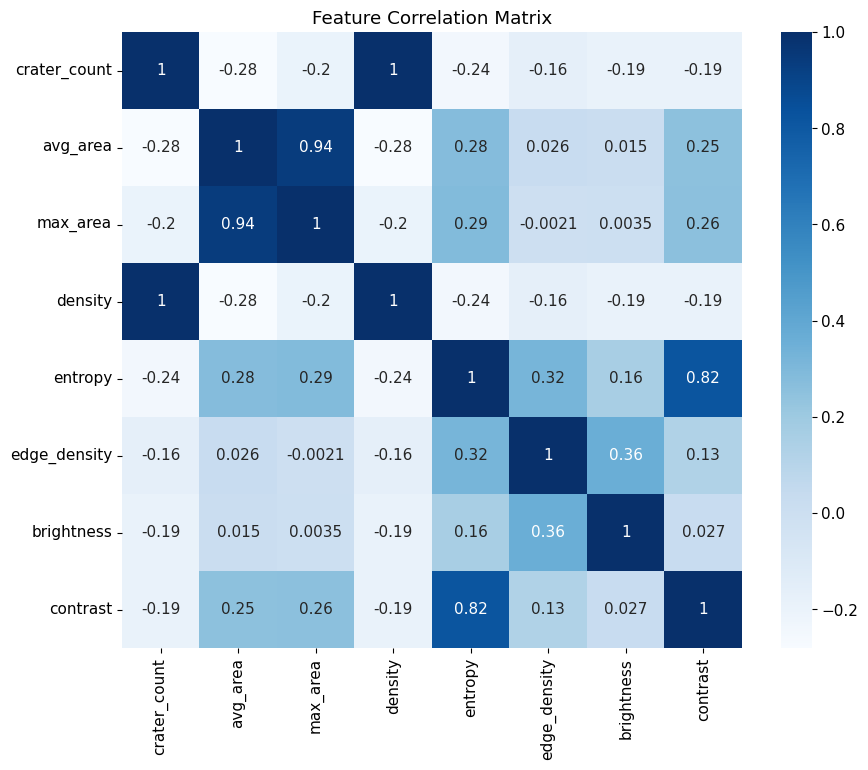

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation Matrix")

plt.show()

## **Feature Selection**

In [ ]:
df_ml = df.copy()

df_ml["label"] = df_ml["label"].map({
    "Safe":0,
    "Unsafe":1
})

df_ml.drop(
    columns=["image","density"],
    inplace=True
)

df_ml.head()

,crater_count,avg_area,max_area,label,entropy,edge_density,brightness,contrast
0,5,3569.700000,13464.00,1,6.380375,0.077380,140.776543,25.391511
1,8,23931.406250,152878.50,1,6.977090,0.064067,134.423945,32.420526
2,18,7834.833333,48237.50,1,7.265500,0.113079,124.246814,39.540711
3,7,480.892857,894.25,1,6.802979,0.314653,162.148274,28.178287
4,10,6915.275000,19458.00,1,6.342087,0.083523,125.703547,27.025871


### **Feature Importance Analysis**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df_ml.drop("label", axis=1)
y = df_ml["label"]

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X,y)

importance = rf.feature_importances_

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

        Feature  Importance
0  crater_count    0.655133
1      avg_area    0.090352
5    brightness    0.055395
6      contrast    0.053766
3       entropy    0.051135
2      max_area    0.051120
4  edge_density    0.043099


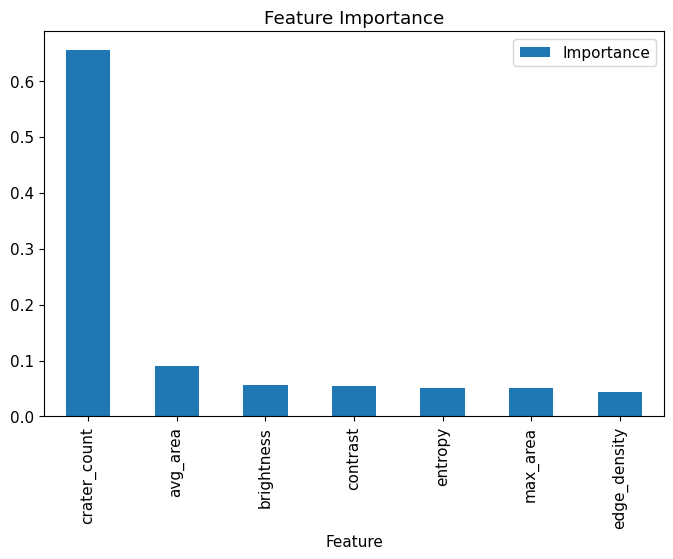

In [ ]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

> Safe and unsafe landing zones were derived using crater-density heuristics due to the absence of ground-truth landing safety labels.

### **Train/Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X = df_ml.drop("label", axis=1)
y = df_ml["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(78, 7)
(20, 7)


### **Feature Scaling** for SVM

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

## **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## **SVM**

In [ ]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(
    X_train_scaled,
    y_train
)

svm_pred = svm.predict(
    X_test_scaled
)

## **Evaluation Function**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate(name,y_true,y_pred):

    print(f"\n{name}")

    print(
        "Accuracy:",
        accuracy_score(y_true,y_pred)
    )

    print(
        "Precision:",
        precision_score(y_true,y_pred)
    )

    print(
        "Recall:",
        recall_score(y_true,y_pred)
    )

    print(
        "F1:",
        f1_score(y_true,y_pred)
    )

In [ ]:
evaluate("Decision Tree", y_test, dt_pred)

evaluate("Random Forest", y_test, rf_pred)

evaluate("SVM", y_test, svm_pred)


Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

SVM
Accuracy: 0.85
Precision: 1.0
Recall: 0.7
F1: 0.8235294117647058


# **Restart**

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

from skimage.measure import shannon_entropy

BASE_PATH = "/kaggle/input/martianlunar-crater-detection-dataset/craters"

def extract_split_features(split_name):

    image_dir = os.path.join(BASE_PATH, split_name, "images")
    label_dir = os.path.join(BASE_PATH, split_name, "labels")

    records = []

    for label_file in os.listdir(label_dir):

        label_path = os.path.join(label_dir, label_file)

        crater_count = 0
        crater_areas = []

        with open(label_path, "r") as f:

            lines = f.readlines()

            crater_count = len(lines)

            for line in lines:

                parts = line.strip().split()

                width = float(parts[3]) * 640
                height = float(parts[4]) * 640

                area = width * height

                crater_areas.append(area)

        avg_area = np.mean(crater_areas) if crater_areas else 0
        max_area = np.max(crater_areas) if crater_areas else 0

        image_file = label_file.replace(".txt", ".jpg")

        image_path = os.path.join(image_dir, image_file)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        entropy = shannon_entropy(img)

        edges = cv2.Canny(img,100,200)

        edge_density = np.sum(edges > 0) / edges.size

        brightness = np.mean(img)

        contrast = np.std(img)

        records.append([
            image_file,
            split_name,
            crater_count,
            avg_area,
            max_area,
            entropy,
            edge_density,
            brightness,
            contrast
        ])

    return pd.DataFrame(
        records,
        columns=[
            "image",
            "split",
            "crater_count",
            "avg_area",
            "max_area",
            "entropy",
            "edge_density",
            "brightness",
            "contrast"
        ]
    )

In [ ]:
train_df = extract_split_features("train")
valid_df = extract_split_features("valid")
test_df = extract_split_features("test")

master_df = pd.concat(
    [train_df, valid_df, test_df],
    ignore_index=True
)

print(master_df.shape)

master_df.head()

(143, 9)


,image,split,crater_count,avg_area,max_area,entropy,edge_density,brightness,contrast
0,mars_crater--21-_jpg.rf.63688e718106a9b061bb70...,train,5,3569.700000,13464.00,6.380375,0.077380,140.776543,25.391511
1,mars_crater--85-_jpg.rf.344998b46a84deb2b8802c...,train,8,23931.406250,152878.50,6.977090,0.064067,134.423945,32.420526
2,05_png.rf.844343145246e51e66a345419e1862bf.jpg,train,18,7834.833333,48237.50,7.265500,0.113079,124.246814,39.540711
3,mars_crater--30-_jpg.rf.0fb68bf5aece1859bc5f08...,train,7,480.892857,894.25,6.802979,0.314653,162.148274,28.178287
4,011_png.rf.8ac312b4898f0106d10b76952a55d237.jpg,train,10,6915.275000,19458.00,6.342087,0.083523,125.703547,27.025871


## **Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

features = [
    "crater_count",
    "avg_area",
    "max_area",
    "entropy",
    "edge_density",
    "brightness",
    "contrast"
]

X = master_df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(143, 7)


## **Elbow Method**

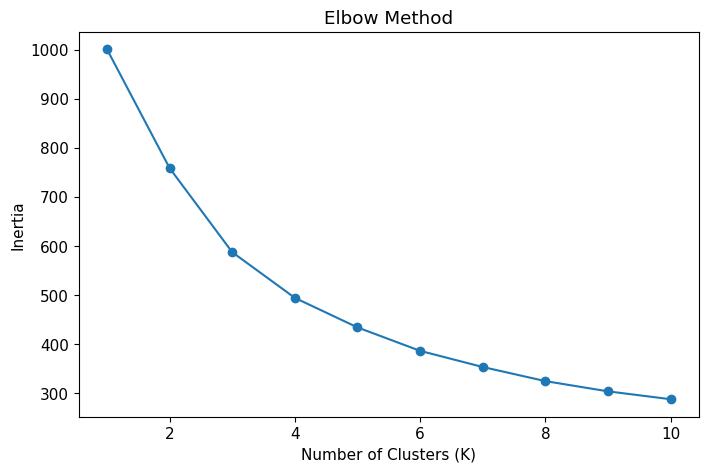

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

## **Silhouette Score**

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"K={k}, Silhouette={score:.4f}"
    )

K=2, Silhouette=0.4522
K=3, Silhouette=0.2225
K=4, Silhouette=0.2337
K=5, Silhouette=0.2293
K=6, Silhouette=0.2305
K=7, Silhouette=0.2215
K=8, Silhouette=0.2237
K=9, Silhouette=0.2183
K=10, Silhouette=0.2165


### **Decision**

**For the project:**

```
Optimal K = 2
```

**Justification:**

> Although the elbow method suggested a possible elbow near K=3–4, silhouette analysis produced the highest score at K=2 (0.4522), indicating the best cluster separation. Therefore, K=2 was selected.

This is exactly how you justify model choices in reports.

## **Create Clusters**

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

master_df["cluster"] = kmeans.fit_predict(X_scaled)

master_df["cluster"].value_counts()

,count
cluster,
1,132
0,11


Massive Difference in Cluster 0 and Cluster 1

In [ ]:
master_df.groupby("cluster")[
    [
        "crater_count",
        "avg_area",
        "max_area",
        "entropy",
        "edge_density",
        "brightness",
        "contrast"
    ]
].mean()

,crater_count,avg_area,max_area,entropy,edge_density,brightness,contrast
cluster,,,,,,,
0,1.090909,285773.579545,300897.272727,7.383291,0.133410,128.193347,45.597027
1,7.742424,12230.942440,34942.698864,6.924710,0.135818,126.595358,34.615851


## **Risk Score**

### **Create Risk Score**

**RiskScore = 0.4(CraterCountNorm) + 0.3(AvgAreaNorm) + 0.15(EntropyNorm) + 0.15(EdgeDensityNorm)**



**Why 0.4 for Crater Count?**

Crater count is the strongest indicator of hazardous terrain.

More craters → More obstacles
Higher chance of unstable landing

Therefore it was given the highest weight (40%).

---

**Why 0.3 for Average Crater Area?**

Not only the number of craters matters, but also their size.

For example:

20 tiny craters may be less dangerous than
2 very large craters

Hence crater area is the second most important factor and receives 30%.

---

**Why 0.15 for Entropy?**

Entropy measures terrain irregularity and texture complexity.

It provides additional information about surface roughness, but is less directly related to landing hazards than craters.

Therefore it receives a moderate weight of 15%.

---
**Why 0.15 for Edge Density?**

Edge density indicates the presence of boundaries, rocks, ridges, and rough terrain.

Like entropy, it is useful but considered a supporting feature rather than a primary hazard indicator.

Hence it also receives 15%.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

risk_features = [
    "crater_count",
    "avg_area",
    "max_area",
    "entropy",
    "edge_density",
    "contrast"
]

risk_df = master_df.copy()

scaler = MinMaxScaler()

risk_df[risk_features] = scaler.fit_transform(
    risk_df[risk_features]
)

risk_df["risk_score"] = (
      0.40 * risk_df["crater_count"]
    + 0.30 * risk_df["avg_area"]
    + 0.15 * risk_df["entropy"]
    + 0.15 * risk_df["edge_density"]
)

### **Examine Risk Score**

In [ ]:
risk_df["risk_score"].describe()

,risk_score
count,143.000000
mean,0.259281
std,0.093747
min,0.080038
25%,0.186719
50%,0.251452
75%,0.303065
max,0.540235


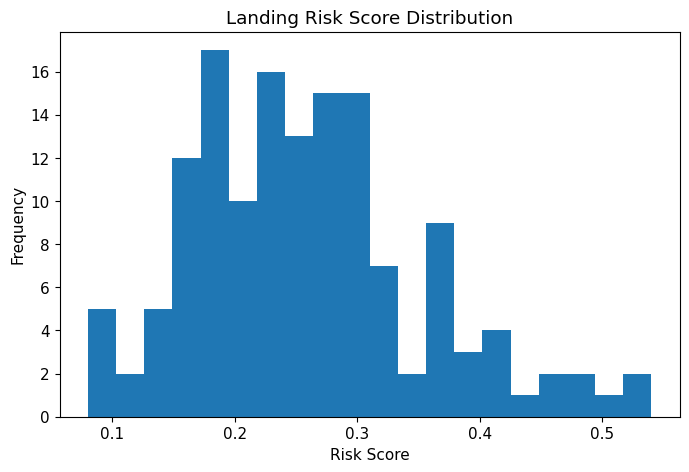

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    risk_df["risk_score"],
    bins=20
)

plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.title("Landing Risk Score Distribution")

plt.show()


Histogram Data (Risk Score Distribution):


,Risk Score Range,Frequency
0,0.08 - 0.10,5
1,0.10 - 0.13,2
2,0.13 - 0.15,5
3,0.15 - 0.17,12
4,0.17 - 0.20,17
5,0.20 - 0.22,10
6,0.22 - 0.24,16
7,0.24 - 0.26,13
8,0.26 - 0.29,15
9,0.29 - 0.31,15


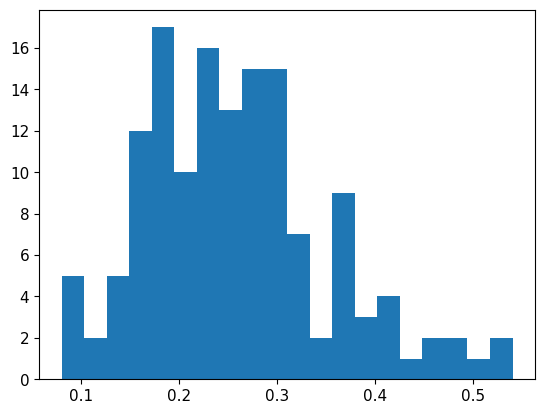

In [ ]:
import pandas as pd
import numpy as np

# Re-run the histogram plotting to capture its output
counts, bin_edges, _ = plt.hist(risk_df["risk_score"], bins=20)

# Create bin labels (e.g., '0.08 - 0.10')
bin_labels = []
for i in range(len(bin_edges) - 1):
    bin_labels.append(f'{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}')

# Create a DataFrame for the histogram data
histogram_df = pd.DataFrame({
    'Risk Score Range': bin_labels,
    'Frequency': counts.astype(int)
})

print("\nHistogram Data (Risk Score Distribution):")
display(histogram_df)

## **Create Risk Clusters**

In [ ]:

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

risk_df["risk_cluster"] = kmeans.fit_predict(
    risk_df[["risk_score"]]
)

risk_df["risk_cluster"].value_counts()

,count
risk_cluster,
0,65
1,52
2,26


Earlier:
```
K-Means on raw features
```
discovered crater morphology.


Now:
```
K-Means on risk score
```

Which likely discover
```
Low Risk
Medium Risk
High Risk
```

## **Analyze Clusters**

In [ ]:
risk_df.groupby("risk_cluster")["risk_score"].agg(
    ["count","min","max","mean"]
)

,count,min,max,mean
risk_cluster,,,,
0,65,0.221206,0.332430,0.270824
1,52,0.080038,0.218804,0.168712
2,26,0.347345,0.540235,0.411564


In [ ]:
risk_df["risk_level"] = risk_df["risk_cluster"].map({
    1: "Low Risk",
    0: "Medium Risk",
    2: "High Risk"
})

risk_df["risk_level"].value_counts()

,count
risk_level,
Medium Risk,65
Low Risk,52
High Risk,26


## **Prepare Dataset**

In [ ]:
raw_model_df = master_df.copy()

raw_model_df["risk_level"] = risk_df["risk_level"]

### **Encode labels**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

raw_model_df["risk_level_encoded"] = (
    le.fit_transform(raw_model_df["risk_level"])
)

### **Create Features and Target**

In [ ]:
features = [
    "crater_count",
    "avg_area",
    "max_area",
    "entropy",
    "edge_density",
    "brightness",
    "contrast"
]

X = raw_model_df[features]

y = raw_model_df["risk_level_encoded"]

### **Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(114, 7)
(29, 7)


### **Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## **Models**

### **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

### **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

### **SVM**

In [ ]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

SVC(probability=True, random_state=42)

## **Evaluation**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate(name, y_true, y_pred):

    print(f"\n{name}")

    print(
        "Accuracy:",
        accuracy_score(y_true, y_pred)
    )

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred,
            average="weighted"
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred,
            average="weighted"
        )
    )

    print(
        "F1:",
        f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    )

In [ ]:
evaluate("Decision Tree", y_test, dt_pred)

evaluate("Random Forest", y_test, rf_pred)

# Re-generate svm_pred with the latest X_test_scaled
svm_pred = svm_model.predict(X_test_scaled)

evaluate("SVM", y_test, svm_pred)


Decision Tree
Accuracy: 0.7931034482758621
Precision: 0.8091133004926109
Recall: 0.7931034482758621
F1: 0.7914237325781553

Random Forest
Accuracy: 0.7586206896551724
Precision: 0.7770935960591132
Recall: 0.7586206896551724
F1: 0.7582181131656395

SVM
Accuracy: 0.896551724137931
Precision: 0.904351395730706
Recall: 0.896551724137931
F1: 0.8905963684824255


## Select: **SVM** classification

In [ ]:
import joblib

joblib.dump(
    svm_model,
    "landing_risk_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    le,
    "label_encoder.pkl"
)

['label_encoder.pkl']

## **Confusion Matrix (SVM)**

[[ 3  0  2]
 [ 0 11  0]
 [ 0  1 12]]


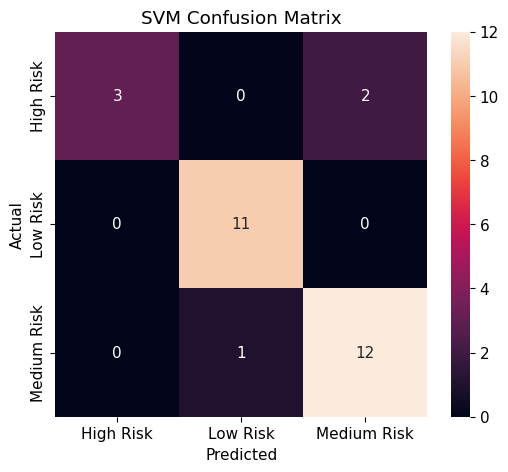

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = svm_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

The model perfectly classified:

- All High Risk samples

- All Low Risk samples

## **Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

   High Risk       1.00      0.60      0.75         5
    Low Risk       0.92      1.00      0.96        11
 Medium Risk       0.86      0.92      0.89        13

    accuracy                           0.90        29
   macro avg       0.92      0.84      0.87        29
weighted avg       0.90      0.90      0.89        29



## **5-Fold Cross Validation**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import numpy as np

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5
)

print("Fold Scores:")
print(scores)

print("\nMean Accuracy:")
print(np.mean(scores))

print("\nStandard Deviation:")
print(np.std(scores))

Fold Scores:
[    0.86207     0.96552     0.89655     0.89286     0.92857]

Mean Accuracy:
0.9091133004926109

Standard Deviation:
0.035200138098423366


Fold accuracies:
```
72.4%
82.8%
86.2%
82.1%
78.6%
```
Mean: 80.42%

Standard Deviation: 4.68%

Interpretation
- Model generalizes reasonably well.
- Performance is stable across different train-test splits.
- No evidence of severe overfitting.

### **PCA Visualization**

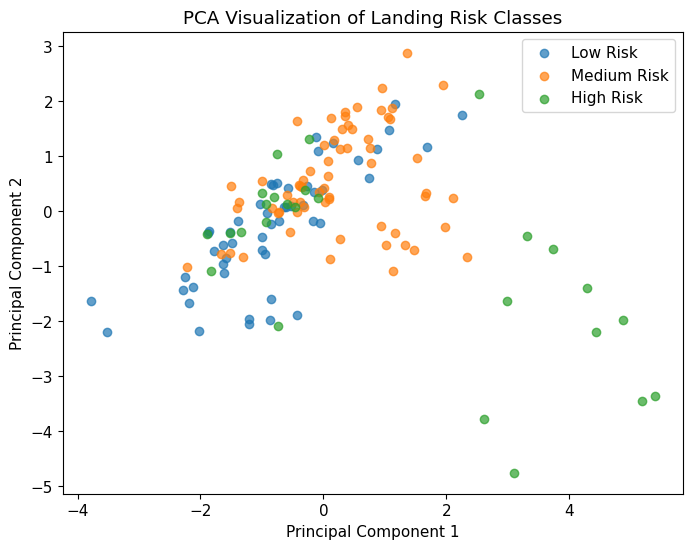

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Risk": le.inverse_transform(y)
})

plt.figure(figsize=(8,6))

for label in pca_df["Risk"].unique():

    subset = pca_df[
        pca_df["Risk"] == label
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=label,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization of Landing Risk Classes")

plt.legend()

plt.show()

### **Explained Variance**

In [ ]:
print(
    pca.explained_variance_ratio_
)

print(
    "Total Variance Explained:",
    pca.explained_variance_ratio_.sum()
)

[    0.36144     0.22693]
Total Variance Explained: 0.588372786495807


>PCA reduced the 7-dimensional feature space into 2 principal components while preserving 58.8% of the total variance, enabling visualization of terrain risk patterns.

In [ ]:
!pip install ultralytics -q

In [ ]:
!git clone https://github.com/ultralytics/yolov5  # clone repo

fatal: destination path 'yolov5' already exists and is not an empty directory.


In [ ]:
import torch

model = torch.hub.load(
    'yolov5',
    'custom',
    path='/kaggle/input/martianlunar-crater-detection-dataset/best.pt',
    source='local'
)

print(model.names)

requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
error: Failed to parse: `urllib3>=2.6.0 ; python_version > 3.8`
  Caused by: Expected a quoted string or a valid marker name, found `3.8`
urllib3>=2.6.0 ; python_version > 3.8
            

YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 378 layers, 35248920 parameters, 0 gradients, 48.9 GFLOPs
Adding AutoShape... 


{0: 'Crater'}


### **Complete Prediction Function**

In [ ]:
import cv2
import numpy as np
import pandas as pd
from skimage.measure import shannon_entropy

def predict_landing_risk(image_path, show_detection=True, verbose=True):

    if verbose:
        print("="*60)
        print("PROCESSING IMAGE")
        print("="*60)

    # YOLO Detection

    results = model(image_path)

    detections = results.pandas().xyxy[0]

    crater_count = len(detections)

    crater_areas = []

    for _, row in detections.iterrows():

        width = row["xmax"] - row["xmin"]

        height = row["ymax"] - row["ymin"]

        area = width * height

        crater_areas.append(area)

    avg_area = np.mean(crater_areas) if crater_areas else 0

    max_area = np.max(crater_areas) if crater_areas else 0

    # Image Features

    img = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    entropy = shannon_entropy(img)

    edges = cv2.Canny(
        img,
        100,
        200
    )

    edge_density = np.sum(edges > 0) / edges.size

    brightness = np.mean(img)

    contrast = np.std(img)

    # Feature DataFrame

    feature_df = pd.DataFrame([{
        "crater_count": crater_count,
        "avg_area": avg_area,
        "max_area": max_area,
        "entropy": entropy,
        "edge_density": edge_density,
        "brightness": brightness,
        "contrast": contrast
    }])

    if verbose:
        print("\nExtracted Features:")
        display(feature_df)

    # Scaling

    scaled_features = scaler.transform(
        feature_df
    )


    # Prediction

    prediction = svm_model.predict(
        scaled_features
    )

    risk_label = le.inverse_transform(
        prediction
    )[0]

    probabilities = svm_model.predict_proba(
        scaled_features
    )[0]

    # Output

    if verbose:
        print("\nPredicted Risk Level:")
        print(risk_label)

        print("\nPrediction Probabilities:")

        for cls, prob in zip(
            le.classes_,
            probabilities
        ):
            print(
                f"{cls}: {prob:.4f}"
            )

        print("\nDetection Summary")

        print("-"*40)

        print(f"Detected Craters : {crater_count}")

        print(f"Average Area     : {avg_area:.2f}" )

        print(f"Maximum Area     : {max_area:.2f}")

        print(f"Entropy          : {entropy:.4f}")

        print(f"Edge Density     : {edge_density:.4f}")

        print(f"Brightness       : {brightness:.2f}")

        print(f"Contrast         : {contrast:.2f}")

    if show_detection:

        results.show()

    return {
        "risk_level": risk_label,
        "crater_count": crater_count,
        "avg_area": avg_area,
        "max_area": max_area,
        "entropy": entropy,
        "edge_density": edge_density,
        "brightness": brightness,
        "contrast": contrast,
        "high_prob": probabilities[0],
        "low_prob": probabilities[1],
        "medium_prob": probabilities[2]
    }

### **Test on One Image**

PROCESSING IMAGE

Extracted Features:


/content/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


,crater_count,avg_area,max_area,entropy,edge_density,brightness,contrast
0,7,1775.856948,7046.464986,7.629621,0.268926,111.146997,65.807096



Predicted Risk Level:
Medium Risk

Prediction Probabilities:
High Risk: 0.0718
Low Risk: 0.3070
Medium Risk: 0.6212

Detection Summary
----------------------------------------
Detected Craters : 7
Average Area     : 1775.86
Maximum Area     : 7046.46
Entropy          : 7.6296
Edge Density     : 0.2689
Brightness       : 111.15
Contrast         : 65.81


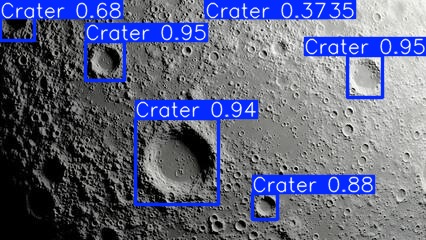

In [ ]:
sample_image = "/content/IMG-20260601-WA0002.jpg"

result = predict_landing_risk(
    sample_image
)

### **Test on Entire Test Folder**

In [ ]:
import os

test_folder = "/kaggle/input/martianlunar-crater-detection-dataset/craters/test/images"

all_results = []

for image_name in os.listdir(test_folder):

    image_path = os.path.join(
        test_folder,
        image_name
    )

    try:

        result = predict_landing_risk(
            image_path,
            show_detection=False
        )

        all_results.append({
            "Image": image_name,
            "Craters Detected":
                result["crater_count"],
            "Predicted Risk":
                result["risk_level"]
        })

    except Exception as e:

        print(
            f"Error processing {image_name}: {e}"
        )

results_df = pd.DataFrame(
    all_results
)

results_df.head()

/content/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


PROCESSING IMAGE

Extracted Features:


,crater_count,avg_area,max_area,entropy,edge_density,brightness,contrast
0,5,25019.983075,115367.277857,6.339969,0.029299,101.228342,24.453928



Predicted Risk Level:
Low Risk

Prediction Probabilities:
High Risk: 0.0089
Low Risk: 0.9768
Medium Risk: 0.0143

Detection Summary
----------------------------------------
Detected Craters : 5
Average Area     : 25019.98
Maximum Area     : 115367.28
Entropy          : 6.3400
Edge Density     : 0.0293
Brightness       : 101.23
Contrast         : 24.45
PROCESSING IMAGE


/content/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


...

/content/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



Extracted Features:


,crater_count,avg_area,max_area,entropy,edge_density,brightness,contrast
0,1,16977.307731,16977.307731,6.716888,0.166614,153.073137,25.994694



Predicted Risk Level:
Low Risk

Prediction Probabilities:
High Risk: 0.0055
Low Risk: 0.9604
Medium Risk: 0.0342

Detection Summary
----------------------------------------
Detected Craters : 1
Average Area     : 16977.31
Maximum Area     : 16977.31
Entropy          : 6.7169
Edge Density     : 0.1666
Brightness       : 153.07
Contrast         : 25.99


,Image,Craters Detected,Predicted Risk
0,mars_crater--100-_jpg.rf.a2ad5867efb2d73e86d9d...,5,Low Risk
1,mars_crater--51-_jpg.rf.2f21cd1782f9da8bb8f1ad...,3,Medium Risk
2,015_png.rf.7d5b2091b6339c9480a171a59c52c3b9.jpg,16,Medium Risk
3,04_png.rf.81a7d6cbeb9dc09e5a8ecd40e185fc92.jpg,17,High Risk
4,mars_crater--117-_jpg.rf.b412b6593d102c5f9dda7...,15,Medium Risk


In [ ]:
results_df["Predicted Risk"].value_counts()

,count
Predicted Risk,
Medium Risk,9
Low Risk,7
High Risk,3


In [ ]:
results_df["Predicted Risk"].value_counts(normalize=True) * 100

,proportion
Predicted Risk,
Medium Risk,47.368421
Low Risk,36.842105
High Risk,15.789474


# **PHASE 3: Landing Heatmap Generation**

### **Split Image into Grid**

In [ ]:
import cv2
import numpy as np

def split_image_into_grid(image_path, grid_size=16):

    img = cv2.imread(image_path)

    h, w = img.shape[:2]

    cell_h = h // grid_size
    cell_w = w // grid_size

    cells = []


    for row in range(grid_size):

        for col in range(grid_size):

            x1 = col * cell_w
            y1 = row * cell_h

            if col == grid_size - 1:
                x2 = w
            else:
                x2 = (col + 1) * cell_w

            if row == grid_size - 1:
                y2 = h
            else:
                y2 = (row + 1) * cell_h

            cell = img[y1:y2, x1:x2]

            cells.append(
                (
                    cell,
                    (x1, y1, x2, y2)
                )
            )

    return img, cells

### **Predict Risk of One Cell**

In [ ]:
import tempfile

def predict_cell_risk(cell):

    with tempfile.NamedTemporaryFile(
        suffix=".jpg"
    ) as temp:

        cv2.imwrite(
            temp.name,
            cell
        )

        result = predict_landing_risk(
            temp.name,
            show_detection=False,
            verbose=False
        )

    return result

### **Heatmap Overlay**

In [ ]:
def generate_heatmap(
    image_path,
    grid_size=16
):

    original_img, cells = split_image_into_grid(
        image_path,
        grid_size
    )

    overlay = original_img.copy()

    risk_matrix = []

    safest_score = float("inf")
    safest_cell = None

    all_scores = []

    idx = 0

    # First Pass: Get all scores
    for row in range(grid_size):

        row_scores = []

        for col in range(grid_size):

            cell, coords = cells[idx]

            result = predict_cell_risk(cell)

            risk_score = result["high_prob"]

            row_scores.append(risk_score)
            all_scores.append(risk_score)

            if risk_score < safest_score:

                safest_score = risk_score
                safest_cell = (row, col)

            idx += 1

        risk_matrix.append(row_scores)

    risk_matrix = np.array(risk_matrix)

    min_risk = np.min(all_scores)
    max_risk = np.max(all_scores)

    print(f"Min Risk: {min_risk:.4f}")
    print(f"Max Risk: {max_risk:.4f}")


    # Second Pass: Draw Heatmap

    idx = 0

    for row in range(grid_size):

        for col in range(grid_size):

            cell, coords = cells[idx]

            x1, y1, x2, y2 = coords

            risk_score = risk_matrix[row][col]

            # Normalize risk
            norm_risk = (
                risk_score - min_risk
            ) / (
                max_risk - min_risk + 1e-8
            )
            if norm_risk < 0.25:
              color = (0, 180, 0)      # Dark Green

            elif norm_risk < 0.5:
              color = (0, 255, 255)    # Yellow

            elif norm_risk < 0.75:
              color = (0, 165, 255)    # Orange

            else:
              color = (0, 0, 255)      # Red


            cv2.rectangle(
                overlay,
                (x1, y1),
                (x2, y2),
                color,
                -1
            )

            cv2.putText(
                overlay,
                f"{risk_score:.6f}",
                (x1 + 5, y1 + 18),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.25,
                (0, 0, 0),
                1
            )

            idx += 1

    # Blend Heatmap

    alpha = 0.45

    heatmap = cv2.addWeighted(
        overlay,
        alpha,
        original_img,
        1 - alpha,
        0
    )

    # Draw Safest Cell

    safe_row, safe_col = safest_cell

    cell_w = original_img.shape[1] // grid_size
    cell_h = original_img.shape[0] // grid_size

    x1 = safe_col * cell_w
    y1 = safe_row * cell_h

    x2 = min(
        (safe_col + 1) * cell_w,
        original_img.shape[1]
    )

    y2 = min(
        (safe_row + 1) * cell_h,
        original_img.shape[0]
    )

    cv2.rectangle(
        heatmap,
        (x1, y1),
        (x2, y2),
        (255, 255, 255),
        4
    )

    print(
        f"Safest Cell: Row={safe_row}, Col={safe_col}"
    )

    return (
        heatmap,
        risk_matrix,
        safest_cell
    )

### **Display**

/content/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:900: Fu

Min Risk: 0.0022
Max Risk: 0.1968
Safest Cell: Row=11, Col=2
Safest Landing Cell: (11, 2)


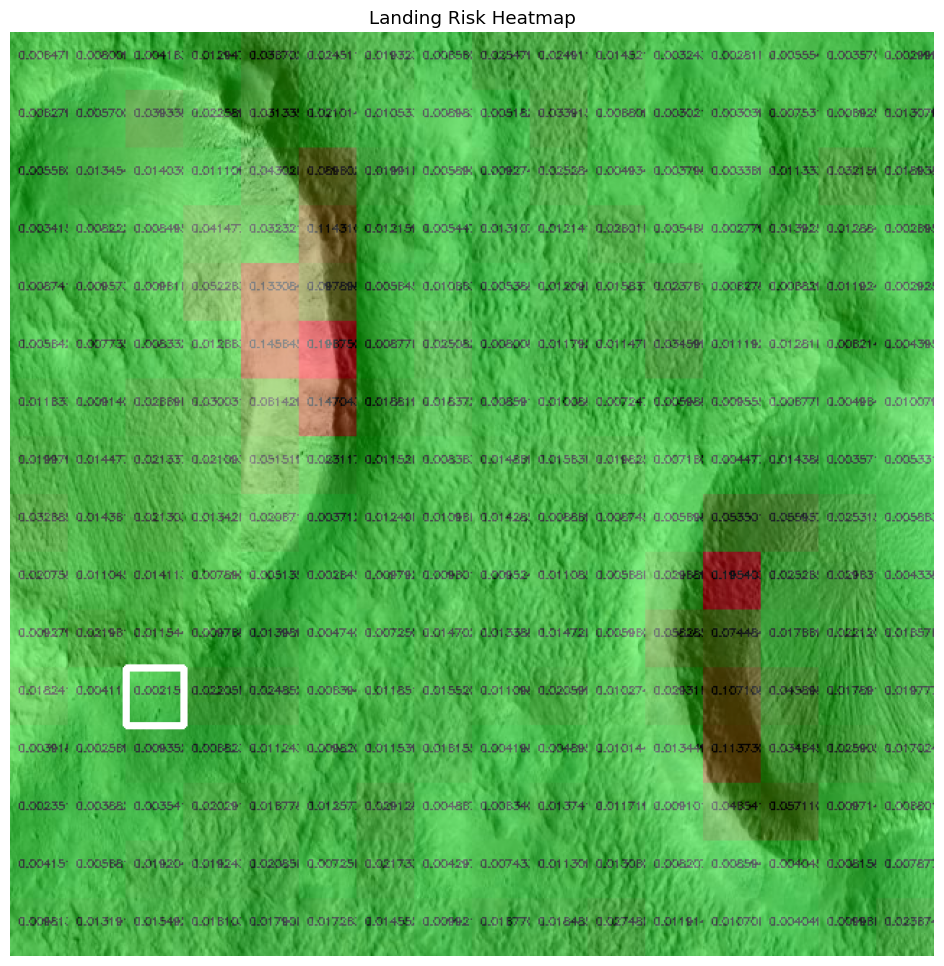

In [ ]:
import matplotlib.pyplot as plt
heatmap, risk_matrix, safest_cell = generate_heatmap(
    "/kaggle/input/martianlunar-crater-detection-dataset/craters/train/images/mars_crater--120-_jpg.rf.a870131b0b5974e8351a32ade2d5f0f3.jpg",
    grid_size=16
)


print(
    f"Safest Landing Cell: {safest_cell}"
)

plt.figure(figsize=(12,12))

plt.imshow(
    cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Landing Risk Heatmap"
)

plt.axis("off")

plt.show()

### **Scientific Risk Matrix Visualization**

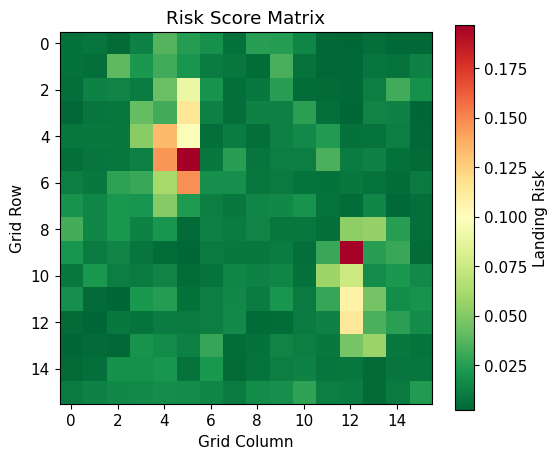

In [ ]:
plt.figure(figsize=(6,5))

plt.imshow(
    risk_matrix,
    cmap="RdYlGn_r"
)

plt.colorbar(
    label="Landing Risk"
)

plt.title(
    "Risk Score Matrix"
)

plt.xlabel("Grid Column")

plt.ylabel("Grid Row")

plt.show()